# Objective 3 — Predictive Model of LLM Characteristics from Benchmarks


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor

# ── Consistent visual style (pastel blue palette) ────────────────────
BLUE      = "#A8D0E6"
DARK_BLUE = "#5DADE2"
SOFT_BLUE = "#D6EAF8"
ACCENT    = "#85C1E9"
TEXT      = "#2C3E50"
RED       = "#E74C3C"
GREEN     = "#2ECC71"

plt.rcParams.update({
    "axes.facecolor":   "#F8FBFF",
    "figure.facecolor": "white",
    "axes.edgecolor":   "#D0D7E2",
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "grid.color":       "#E5ECF6",
    "font.size":        11,
    "figure.dpi":       120,
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading and Feature Engineering

We follow the same strategy as `variables.ipynb`:
- **`flops_entrenamiento`** is cast to numeric (stored as a scientific-notation string).
- **Binary indicator variables** are created for architecture (`is_qwen2`, `is_llama`) and model type (`is_chat`, `is_finetune`, `is_pretrained`), replicating the one-hot encoding produced in Objective 1.
- A **`sample_weight`** vector is built from `confianza_datos` (Confident → 1.0, Speculative → 0.5) so that uncertain observations are down-weighted during training.


In [2]:
df = pd.read_excel("../data/processed/dataset_clean.xlsx")
print(f"Original dataset: {df.shape[0]} rows × {df.shape[1]} columns")

# ── 2.1 Cast training FLOPs to numeric ───────────────────────────────
df['flops_entrenamiento_num'] = pd.to_numeric(df['flops_entrenamiento'], errors='coerce')

# ── 2.2 Binary indicator variables (following variables.ipynb) ───────
# Architecture flags
df['is_qwen2']      = df['arquitectura'].str.contains('Qwen2',    na=False).astype(int)
df['is_llama']      = df['arquitectura'].str.contains('Llama',    na=False).astype(int)
# Model-type flags
df['is_chat']       = (df['tipo_modelo'] == 'chatmodels').astype(int)
df['is_finetune']   = df['tipo_modelo'].str.contains('fine-tuned', na=False).astype(int)
df['is_pretrained'] = (df['tipo_modelo'] == 'pretrained').astype(int)

# ── 2.3 Observation-confidence weight vector ─────────────────────────
weight_map = {'Confident': 1.0, 'Speculative': 0.5}
df['sample_weight'] = df['confianza_datos'].map(weight_map).fillna(0.5)

print(f"\nData-confidence distribution:")
print(df['confianza_datos'].value_counts())
print(f"\nUnique architectures : {df['arquitectura'].nunique()}")
print(f"Unique model types   : {df['tipo_modelo'].nunique()}")


Original dataset: 77 rows × 61 columns

Data-confidence distribution:
confianza_datos
Confident      70
Speculative     7
Name: count, dtype: int64

Unique architectures : 9
Unique model types   : 5


## 3. Feature and Target Definition

| Group | Variables | Model |
|-------|-----------|-------|
| **Features** | `ifeval`, `math`, `gpqa`, `musr`, `reasoning_score` | — |
| **Numerical targets** | `parametros_b` (B params), `flops_entrenamiento_num`, `tamano_dataset` | XGBoost Regressor |
| **Categorical targets** | `is_qwen2`, `is_llama`, `is_chat`, `is_finetune`, `is_pretrained` | RandomForest Classifier |

The five benchmark scores are the **input features**: they summarise a model's capabilities across instruction-following (IFEval), mathematics (MATH), science (GPQA), multi-step reasoning (MUSR), and combined reasoning (reasoning_score, the average of BBH and MMLU-Pro, merged to reduce collinearity).  
The model learns to invert this relationship — given observed performance, predict design decisions.


In [3]:
# ── 3.0 Merge correlated benchmarks into a single reasoning score ─────
benchmarks_to_merge = ["bbh", "mmlu_pro"]
df['reasoning_score'] = df[benchmarks_to_merge].mean(axis=1)
df = df.drop(columns=benchmarks_to_merge)

# ── Input features: the 5 benchmarks (bbh + mmlu_pro → reasoning_score) ─
BENCHMARKS = ['ifeval', 'math', 'gpqa', 'musr', 'reasoning_score']

# ── Regression targets ────────────────────────────────────────────────
TARGETS_NUM        = ['parametros_b', 'flops_entrenamiento_num', 'tamano_dataset']
TARGETS_NUM_LABELS = ['Parameters (B)', 'Training FLOPs', 'Dataset size']

# ── Classification targets ────────────────────────────────────────────
TARGETS_CAT        = ['is_qwen2', 'is_llama', 'is_chat', 'is_finetune', 'is_pretrained']
TARGETS_CAT_LABELS = ['Arch. Qwen2', 'Arch. Llama', 'Type: chat', 'Type: finetune', 'Type: pretrained']

# ── Sanity check: all columns present? ───────────────────────────────
all_cols = BENCHMARKS + TARGETS_NUM + TARGETS_CAT + ['sample_weight', 'modelo_epoch']
missing  = [c for c in all_cols if c not in df.columns]
if missing:
    print(f"Missing columns: {missing}")
else:
    print("All required columns found in the dataset.")

print(f"\nFeatures   (benchmarks)  : {BENCHMARKS}")
print(f"Numerical targets        : {TARGETS_NUM}")
print(f"Categorical targets      : {TARGETS_CAT}")


All required columns found in the dataset.

Features   (benchmarks)  : ['ifeval', 'math', 'gpqa', 'musr', 'reasoning_score']
Numerical targets        : ['parametros_b', 'flops_entrenamiento_num', 'tamano_dataset']
Categorical targets      : ['is_qwen2', 'is_llama', 'is_chat', 'is_finetune', 'is_pretrained']


## 4. Data Cleaning and Train / Test Split

In [4]:
# ── Select relevant columns and drop invalid rows ─────────────────────
df_model = df[BENCHMARKS + TARGETS_NUM + TARGETS_CAT + ['sample_weight', 'modelo_epoch']].copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Rows after cleaning: {len(df_model)}  (original: {len(df)})")

# ── Separate X and y arrays ───────────────────────────────────────────
X       = df_model[BENCHMARKS].values
y_num   = df_model[TARGETS_NUM].values
y_cat   = df_model[TARGETS_CAT].values
weights = df_model['sample_weight'].values

# ── 80/20 split with fixed random seed for reproducibility ───────────
(X_train, X_test,
 y_num_train, y_num_test,
 y_cat_train, y_cat_test,
 w_train, w_test) = train_test_split(
    X, y_num, y_cat, weights,
    test_size=0.20, random_state=42
)

print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")


Rows after cleaning: 77  (original: 77)

Training set : 61 samples
Test set     : 16 samples


## 5. Multi-Output Regression Model — XGBoost

We wrap an **`XGBRegressor`** (n_estimators=300, max_depth=4) inside a **`MultiOutputRegressor`** to predict the three numerical targets simultaneously.  
`sample_weight` is forwarded so that *Speculative* observations exert half the influence of *Confident* ones during training.

**Hyperparameters:**
- `n_estimators=300` — number of boosting rounds per output.
- `max_depth=4` — shallow trees reduce overfitting on this small dataset (n≈77).
- `learning_rate=0.05` — slow shrinkage for more stable generalisation.
- `subsample=0.8` / `colsample_bytree=0.8` — stochastic sampling for variance reduction.


In [5]:
# ── Model definition ──────────────────────────────────────────────────
xgb_base = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)
model_reg = MultiOutputRegressor(xgb_base)

# ── Training ──────────────────────────────────────────────────────────
model_reg.fit(X_train, y_num_train, sample_weight=w_train)

# ── Inference on the test set ─────────────────────────────────────────
y_pred_num = model_reg.predict(X_test)

# ── Per-target metrics ────────────────────────────────────────────────
print("=" * 60)
print("REGRESSION — Test Set Metrics")
print("=" * 60)

reg_results = {}
for i, (target, label) in enumerate(zip(TARGETS_NUM, TARGETS_NUM_LABELS)):
    r2   = r2_score(y_num_test[:, i], y_pred_num[:, i])
    mae  = mean_absolute_error(y_num_test[:, i], y_pred_num[:, i])
    rmse = np.sqrt(mean_squared_error(y_num_test[:, i], y_pred_num[:, i]))
    reg_results[target] = {
        'R²': r2, 'MAE': mae, 'RMSE': rmse,
        'real': y_num_test[:, i], 'pred': y_pred_num[:, i]
    }
    print(f"\n  {label} ({target})")
    print(f"    R²   = {r2:.4f}")
    print(f"    MAE  = {mae:.4e}")
    print(f"    RMSE = {rmse:.4e}")


REGRESSION — Test Set Metrics

  Parameters (B) (parametros_b)
    R²   = 0.1177
    MAE  = 1.4352e+01
    RMSE = 2.4696e+01

  Training FLOPs (flops_entrenamiento_num)
    R²   = -0.0023
    MAE  = 2.1246e+24
    RMSE = 2.4420e+24

  Dataset size (tamano_dataset)
    R²   = 0.1362
    MAE  = 3.8192e+12
    RMSE = 4.6291e+12


## 6. Multi-Output Classification Model — Random Forest

A **`MultiOutputClassifier`** wrapping a **`RandomForestClassifier`** simultaneously predicts the five binary architecture/type indicators.

`class_weight='balanced'` compensates for the natural imbalance in the dataset (e.g. Qwen2 architecture is far more common than Llama in this sample), preventing the classifier from defaulting to the majority class.


In [6]:
# ── Model definition ──────────────────────────────────────────────────
model_clf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42,
        class_weight='balanced'   # compensates class imbalance
    )
)

# ── Training ──────────────────────────────────────────────────────────
model_clf.fit(X_train, y_cat_train)

# ── Inference on the test set ─────────────────────────────────────────
y_pred_cat = model_clf.predict(X_test)

# ── Per-target metrics ────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION — Test Set Metrics")
print("=" * 60)

clf_results = {}
for i, (target, label) in enumerate(zip(TARGETS_CAT, TARGETS_CAT_LABELS)):
    acc = accuracy_score(y_cat_test[:, i], y_pred_cat[:, i])
    clf_results[target] = {
        'Accuracy': acc,
        'real': y_cat_test[:, i],
        'pred': y_pred_cat[:, i]
    }
    print(f"\n  {label} ({target})")
    print(f"    Accuracy = {acc:.3f}")
    print(classification_report(
        y_cat_test[:, i], y_pred_cat[:, i],
        target_names=['No', 'Yes'], zero_division=0
    ))


CLASSIFICATION — Test Set Metrics

  Arch. Qwen2 (is_qwen2)
    Accuracy = 0.750
              precision    recall  f1-score   support

          No       0.57      0.80      0.67         5
         Yes       0.89      0.73      0.80        11

    accuracy                           0.75        16
   macro avg       0.73      0.76      0.73        16
weighted avg       0.79      0.75      0.76        16


  Arch. Llama (is_llama)
    Accuracy = 0.625
              precision    recall  f1-score   support

          No       0.90      0.64      0.75        14
         Yes       0.17      0.50      0.25         2

    accuracy                           0.62        16
   macro avg       0.53      0.57      0.50        16
weighted avg       0.81      0.62      0.69        16


  Type: chat (is_chat)
    Accuracy = 0.688
              precision    recall  f1-score   support

          No       0.83      0.56      0.67         9
         Yes       0.60      0.86      0.71         7

    accur

## 7. Validation — Residual Analysis (Regression)

Residual analysis is the primary diagnostic tool for evaluating a regression model. It lets us detect:

| Diagnostic | What to look for | Ideal outcome |
|---|---|---|
| **Histogram of residuals** | Symmetric bell shape | Mean ≈ 0, no skew |
| **Shapiro-Wilk test** | p-value > 0.05 → normality not rejected | p > 0.05 |
| **Q-Q plot** | Points close to the diagonal | No heavy tails |
| **Residuals vs. Predicted** | Random cloud around 0 | No fan-shape (homoscedasticity) |
| **Residuals vs. each Benchmark** | Flat trend line (slope ≈ 0) | No systematic pattern |

A non-zero slope in *residuals vs. benchmark* signals that the model has not fully exploited the information in that benchmark — an opportunity for further improvement.


In [7]:
def plot_residual_analysis(real, pred, target_name,
                           benchmarks_arr, benchmark_names, color=DARK_BLUE):
    """
    Full residual diagnostic panel for one numerical target.

    Panels produced
    ---------------
    Row 0 : Residual histogram | Q-Q normality plot | Residuals vs. Predicted
    Row 1 : Residuals vs. each input benchmark (scatter + trend line)
    """
    residuals = real - pred

    # ── Shapiro-Wilk normality test ───────────────────────────────────
    stat_sw, p_sw = stats.shapiro(residuals)

    n_bench = len(benchmark_names)
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, n_bench, figure=fig, hspace=0.45, wspace=0.4)

    # ── Row 0, col 0-1 : Residual histogram ──────────────────────────
    ax0 = fig.add_subplot(gs[0, :2])
    ax0.hist(residuals, bins=12, color=color, edgecolor='white', alpha=0.9)
    ax0.axvline(0,                color=RED,   lw=1.5, ls='--', label='Residual = 0')
    ax0.axvline(residuals.mean(), color=GREEN, lw=1.5, ls='--',
                label=f'Mean = {residuals.mean():.2e}')
    ax0.set_title(f'Residual Distribution\n{target_name}', weight='bold')
    ax0.set_xlabel('Residual (actual − predicted)')
    ax0.set_ylabel('Frequency')
    ax0.legend(fontsize=9, frameon=False)
    sw_label = f"Shapiro-Wilk p={p_sw:.3f} {'(normal ✓)' if p_sw > 0.05 else '(non-normal ✗)'}"
    ax0.text(0.97, 0.93, sw_label, transform=ax0.transAxes,
             ha='right', va='top', fontsize=8.5,
             bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.3'))
    ax0.grid(alpha=0.3)

    # ── Row 0, col 2-3 : Q-Q plot ────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 2:4])
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    ax1.scatter(osm, osr, color=color, alpha=0.75, s=30, edgecolors='white', linewidths=0.4)
    qq_line = slope * np.array([osm[0], osm[-1]]) + intercept
    ax1.plot([osm[0], osm[-1]], qq_line, color=RED, lw=1.5, ls='--')
    ax1.set_title(f'Q-Q Plot (Normality Check)\nr = {r:.3f}', weight='bold')
    ax1.set_xlabel('Theoretical quantiles')
    ax1.set_ylabel('Sample quantiles')
    ax1.grid(alpha=0.3)

    # ── Row 0, col 4+ : Residuals vs. Predicted (homoscedasticity) ───
    ax2 = fig.add_subplot(gs[0, 4:])
    ax2.scatter(pred, residuals, color=color, alpha=0.7, s=30,
                edgecolors='white', linewidths=0.4)
    ax2.axhline(0, color=RED, lw=1.5, ls='--')
    sigma = residuals.std()
    ax2.axhline(+2 * sigma, color='#F39C12', lw=1, ls=':', label='±2σ band')
    ax2.axhline(-2 * sigma, color='#F39C12', lw=1, ls=':')
    # Rolling-mean trend line (approximate LOWESS)
    sort_idx = np.argsort(pred)
    smooth_y = (pd.Series(residuals[sort_idx])
                  .rolling(max(2, len(pred) // 4), center=True, min_periods=1)
                  .mean().values)
    ax2.plot(pred[sort_idx], smooth_y, color=GREEN, lw=1.5, label='Trend (rolling mean)')
    ax2.set_title('Residuals vs. Predicted Values', weight='bold')
    ax2.set_xlabel('Predicted Value')
    ax2.set_ylabel('Residual')
    ax2.legend(fontsize=9, frameon=False)
    ax2.grid(alpha=0.3)

    # ── Rows 1-2 : Residuals vs. each benchmark ──────────────────────
    for j, bname in enumerate(benchmark_names):
        row = 1 + j // n_bench
        col = j % n_bench
        ax  = fig.add_subplot(gs[row, col])
        bvals = benchmarks_arr[:, j]
        ax.scatter(bvals, residuals, color=SOFT_BLUE, edgecolors=DARK_BLUE,
                   linewidths=0.5, alpha=0.75, s=28)
        ax.axhline(0, color=RED, lw=1, ls='--')
        if bvals.std() > 0:
            m, b_int, *_ = stats.linregress(bvals, residuals)
            xr = np.linspace(bvals.min(), bvals.max(), 50)
            ax.plot(xr, m * xr + b_int, color=GREEN, lw=1.2)
        ax.set_title(f'Residual vs {bname}', weight='bold', fontsize=9)
        ax.set_xlabel(bname, fontsize=8)
        ax.set_ylabel('Residual', fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

    plt.suptitle(f'Complete Residual Analysis — {target_name}',
                 fontsize=14, weight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return {
        'shapiro_p':      p_sw,
        'mean_residual':  residuals.mean(),
        'std_residual':   residuals.std(),
        'max_abs':        np.abs(residuals).max()
    }



  Residual analysis: Parameters (B)


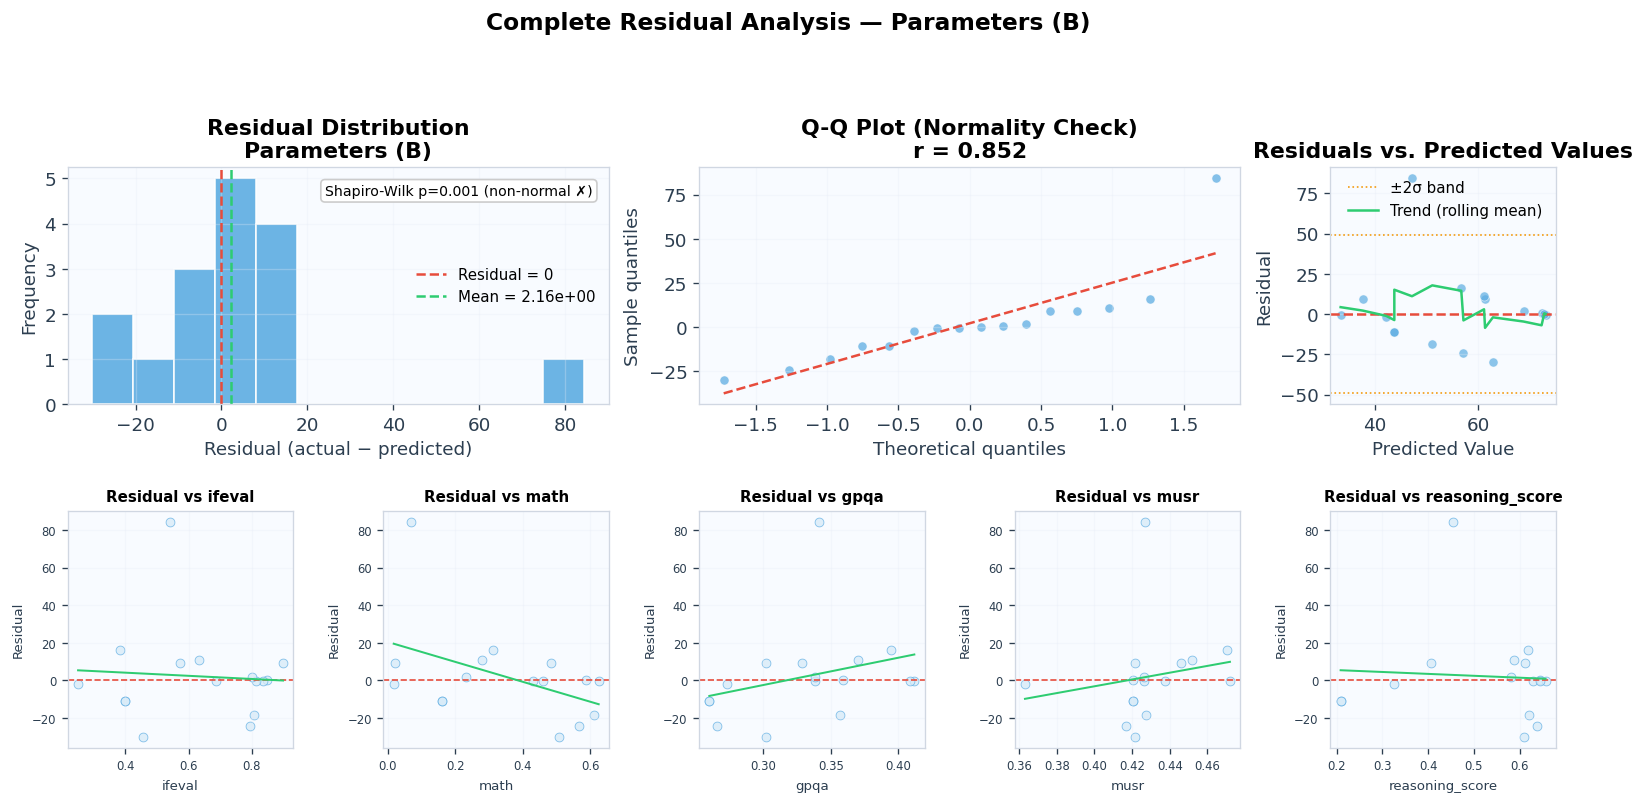

  Residual mean        : 2.1613e+00
  Residual std dev     : 2.4601e+01
  Max absolute error   : 8.4476e+01
  Shapiro-Wilk p-value : 0.0009  (Non-normal ✗)

  Residual analysis: Training FLOPs


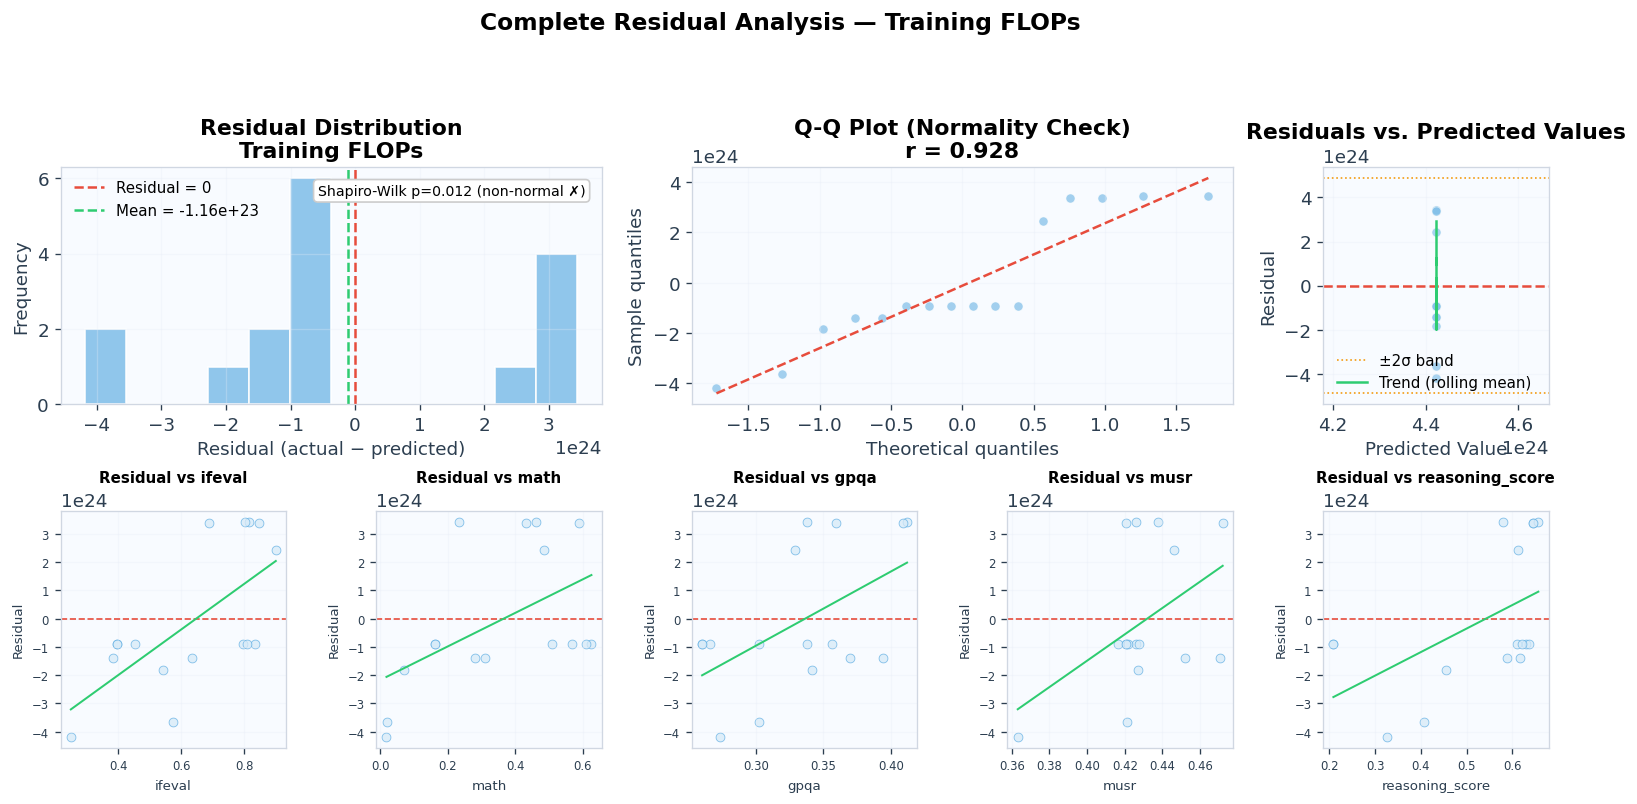

  Residual mean        : -1.1608e+23
  Residual std dev     : 2.4393e+24
  Max absolute error   : 4.1818e+24
  Shapiro-Wilk p-value : 0.0120  (Non-normal ✗)

  Residual analysis: Dataset size


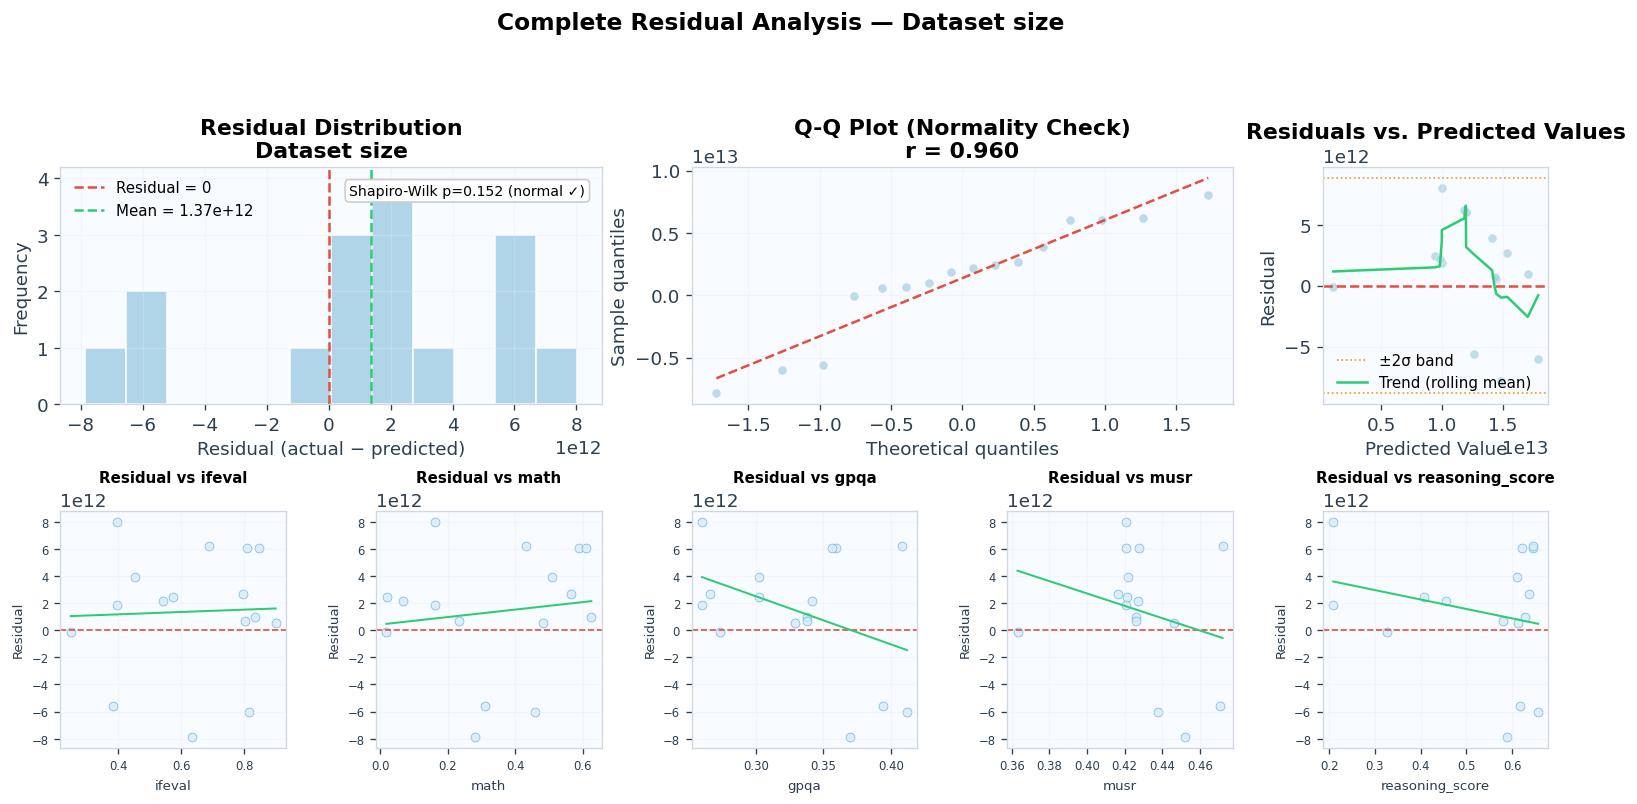

  Residual mean        : 1.3740e+12
  Residual std dev     : 4.4205e+12
  Max absolute error   : 8.0183e+12
  Shapiro-Wilk p-value : 0.1524  (Normal ✓)


In [8]:
# ── Run residual analysis for each numerical target ───────────────────
residual_stats = {}

for i, (target, label) in enumerate(zip(TARGETS_NUM, TARGETS_NUM_LABELS)):
    print(f"\n{'='*60}")
    print(f"  Residual analysis: {label}")
    print(f"{'='*60}")

    stats_out = plot_residual_analysis(
        real            = reg_results[target]['real'],
        pred            = reg_results[target]['pred'],
        target_name     = label,
        benchmarks_arr  = X_test,
        benchmark_names = BENCHMARKS,
        color           = [DARK_BLUE, ACCENT, BLUE][i]
    )
    residual_stats[target] = stats_out

    print(f"  Residual mean        : {stats_out['mean_residual']:.4e}")
    print(f"  Residual std dev     : {stats_out['std_residual']:.4e}")
    print(f"  Max absolute error   : {stats_out['max_abs']:.4e}")
    print(f"  Shapiro-Wilk p-value : {stats_out['shapiro_p']:.4f}  "
          f"({'Normal ✓' if stats_out['shapiro_p'] > 0.05 else 'Non-normal ✗'})")


### 7.1 Actual vs. Predicted — Numerical Targets

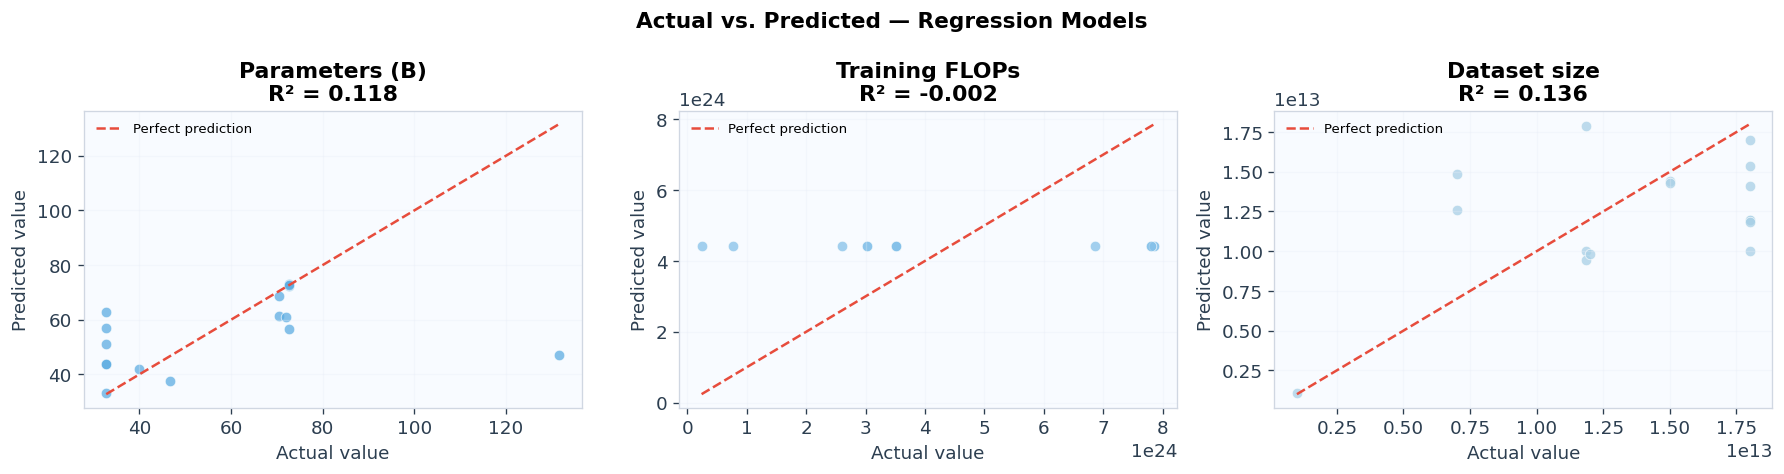

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (target, label) in enumerate(zip(TARGETS_NUM, TARGETS_NUM_LABELS)):
    ax   = axes[i]
    real = reg_results[target]['real']
    pred = reg_results[target]['pred']
    r2   = reg_results[target]['R²']

    ax.scatter(real, pred,
               color=[DARK_BLUE, ACCENT, BLUE][i],
               alpha=0.75, s=40, edgecolors='white', linewidths=0.5)

    # Perfect-prediction diagonal
    mn, mx = min(real.min(), pred.min()), max(real.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], color=RED, lw=1.5, ls='--', label='Perfect prediction')

    ax.set_title(f'{label}\nR² = {r2:.3f}', weight='bold')
    ax.set_xlabel('Actual value')
    ax.set_ylabel('Predicted value')
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs. Predicted — Regression Models', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 7.2 Confusion Matrices — Classification

Each confusion matrix shows how many test samples were correctly/incorrectly labelled for each binary indicator.  
- **True Negatives (top-left)** and **True Positives (bottom-right)** are correct predictions.  
- Off-diagonal cells are errors: **False Positives** (top-right) and **False Negatives** (bottom-left).


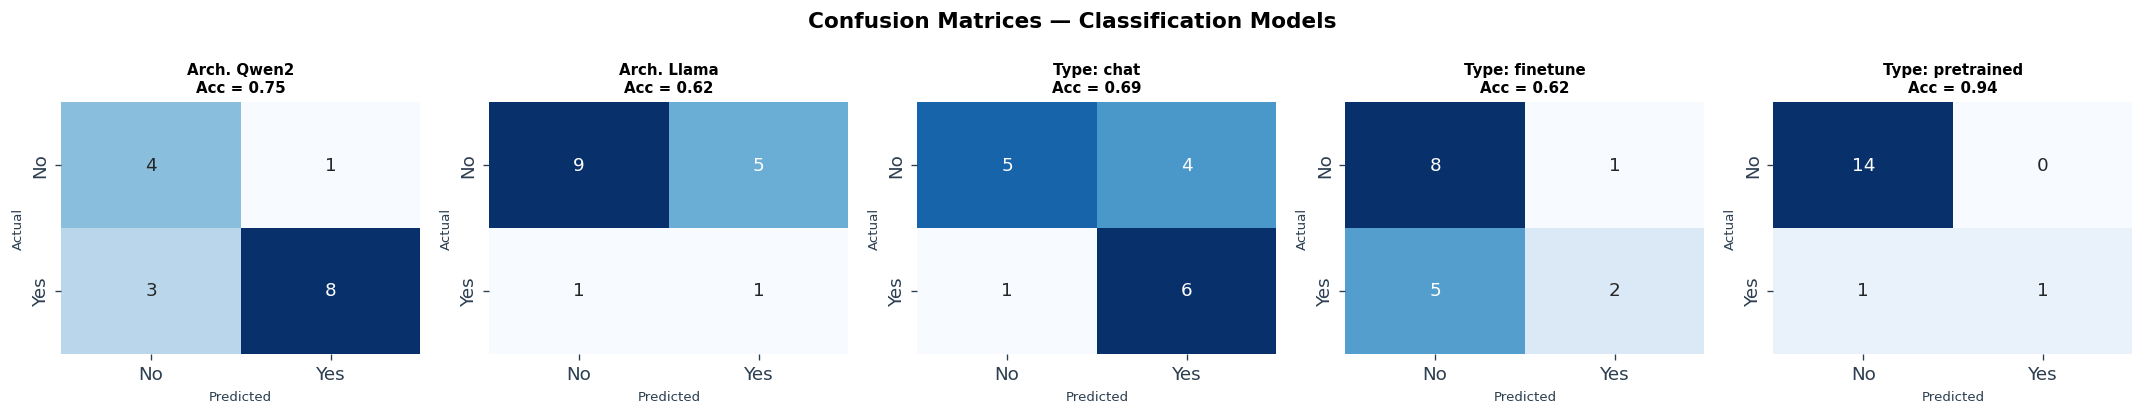

In [10]:
fig, axes = plt.subplots(1, len(TARGETS_CAT), figsize=(18, 3.5))

for i, (target, label) in enumerate(zip(TARGETS_CAT, TARGETS_CAT_LABELS)):
    ax = axes[i]
    cm = confusion_matrix(clf_results[target]['real'], clf_results[target]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    acc = clf_results[target]['Accuracy']
    ax.set_title(f'{label}\nAcc = {acc:.2f}', weight='bold', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual',    fontsize=8)

plt.suptitle('Confusion Matrices — Classification Models', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Consolidated Metrics and Conclusions

In [11]:
# ── Guard: compute residual_stats if section 7 was skipped ──────────
if 'residual_stats' not in dir() or not residual_stats:
    residual_stats = {}
    for i, target in enumerate(TARGETS_NUM):
        real      = reg_results[target]['real']
        pred      = reg_results[target]['pred']
        residuals = real - pred
        from scipy import stats as _stats
        _, p_sw = _stats.shapiro(residuals)
        residual_stats[target] = {
            'mean_residual': residuals.mean(),
            'std_residual':  residuals.std(),
            'max_abs':       float(abs(residuals).max()),
            'shapiro_p':     p_sw,
        }

print("=" * 70)
print("FINAL SUMMARY — OBJECTIVE 3: Predictive Model of LLM Characteristics")
print("=" * 70)

print("\n REGRESSION  (benchmarks → numerical characteristics)\n")
df_reg = pd.DataFrame({
    'Target'    : TARGETS_NUM_LABELS,
    'Variable'  : TARGETS_NUM,
    'R²'        : [reg_results[t]['R²']                for t in TARGETS_NUM],
    'MAE'       : [reg_results[t]['MAE']               for t in TARGETS_NUM],
    'RMSE'      : [reg_results[t]['RMSE']              for t in TARGETS_NUM],
    'Residual μ': [residual_stats[t]['mean_residual']   for t in TARGETS_NUM],
    'Residual σ': [residual_stats[t]['std_residual']    for t in TARGETS_NUM],
    'Shapiro p' : [residual_stats[t]['shapiro_p']       for t in TARGETS_NUM],
})
print(df_reg.to_string(index=False))

print("\n\n CLASSIFICATION  (benchmarks → architecture / model type)\n")
df_clf = pd.DataFrame({
    'Target'   : TARGETS_CAT_LABELS,
    'Variable' : TARGETS_CAT,
    'Accuracy' : [clf_results[t]['Accuracy'] for t in TARGETS_CAT],
})
print(df_clf.to_string(index=False))

print("""
\n RESIDUAL INTERPRETATION GUIDE:
  • Residual mean ≈ 0  →  no systematic bias; the model is not consistently
                          over- or under-predicting.
  • Shapiro-Wilk p > 0.05  →  residuals are compatible with a normal
                              distribution (classical OLS assumption met).
  • Residuals vs. Predicted with no visible pattern  →  homoscedasticity;
                              prediction error is constant across the range.
  • Non-zero slope in Residual vs. Benchmark  →  that benchmark still carries
                              signal the model has not captured; a sign that
                              feature interactions or non-linear terms could
                              improve performance.
""")


FINAL SUMMARY — OBJECTIVE 3: Predictive Model of LLM Characteristics

 REGRESSION  (benchmarks → numerical characteristics)

        Target                Variable        R²          MAE         RMSE    Residual μ   Residual σ  Shapiro p
Parameters (B)            parametros_b  0.117720 1.435226e+01 2.469600e+01  2.161303e+00 2.460124e+01   0.000856
Training FLOPs flops_entrenamiento_num -0.002264 2.124649e+24 2.442033e+24 -1.160769e+23 2.439273e+24   0.012019
  Dataset size          tamano_dataset  0.136237 3.819164e+12 4.629130e+12  1.374014e+12 4.420513e+12   0.152384


 CLASSIFICATION  (benchmarks → architecture / model type)

          Target      Variable  Accuracy
     Arch. Qwen2      is_qwen2    0.7500
     Arch. Llama      is_llama    0.6250
      Type: chat       is_chat    0.6875
  Type: finetune   is_finetune    0.6250
Type: pretrained is_pretrained    0.9375


 RESIDUAL INTERPRETATION GUIDE:
  • Residual mean ≈ 0  →  no systematic bias; the model is not consistently
      

In [13]:
## 9. Save Model Predictions for the Mockup (Segunda Función)

# The mockup's *segunda función* needs, for each model in the dataset:
#   • its benchmark scores (the inputs)  
#   • the predicted numerical characteristics (regression outputs)  
#   • the predicted categorical characteristics (classification outputs)
# Everything is written to  model_predictions.xlsx  in the working directory.

import os

# ── 9.1 Re-run inference on the FULL dataset (not just test split) ────
X_all     = df_model[BENCHMARKS].values
y_pred_num_all = model_reg.predict(X_all)
y_pred_cat_all = model_clf.predict(X_all)

# ── 9.2 Build a tidy results DataFrame ───────────────────────────────
results_df = df_model[['modelo_epoch'] + BENCHMARKS].copy().reset_index(drop=True)

# Numerical predictions
for i, (target, label) in enumerate(zip(TARGETS_NUM, TARGETS_NUM_LABELS)):
    results_df[f'pred_{target}'] = y_pred_num_all[:, i]

# Categorical predictions
for i, target in enumerate(TARGETS_CAT):
    results_df[f'pred_{target}'] = y_pred_cat_all[:, i]

# ── 9.3 Also store actual values for comparison ───────────────────────
for col in TARGETS_NUM + TARGETS_CAT:
    results_df[f'actual_{col}'] = df_model[col].values

print(f"Predictions saved for {len(results_df)} models.")
print(results_df.head())

# ── 9.4 Export ────────────────────────────────────────────────────────
output_path = "model_predictions.xlsx"
results_df.to_excel(output_path, index=False)
print(f"\nSaved to: {os.path.abspath(output_path)}")
print(f"   Columns : {list(results_df.columns)}")


Predictions saved for 77 models.
     modelo_epoch    ifeval      math      gpqa      musr  reasoning_score  \
0         QwQ-32B  0.397674  0.160876  0.260067  0.420635         0.208947   
1         QwQ-32B  0.403544  0.449396  0.281879  0.410990         0.618479   
2       Apollo 7B  0.295333  0.025680  0.278523  0.413125         0.269205   
3  EXAONE 3.5 32B  0.839183  0.512840  0.287752  0.380667         0.519886   
4   Llama 3.3 70B  0.899758  0.483384  0.328859  0.446125         0.612546   

   pred_parametros_b  pred_flops_entrenamiento_num  pred_tamano_dataset  \
0          43.695942                  4.421800e+24         9.981722e+12   
1          32.904099                  4.421800e+24         1.587268e+13   
2           7.669700                  4.421800e+24         1.150067e+13   
3          32.168671                  4.421800e+24         6.545318e+12   
4          61.278404                  4.421800e+24         1.444332e+13   

   pred_is_qwen2  ...  pred_is_finetune  pred_i